In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import pandas_ta as ta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime, timedelta
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import dash
from dash import html, dcc
from dash.dependencies import Output, Input


df = pd.read_csv("data/marketing_campaign.csv")

df["Date"] = pd.to_datetime(df["Date"])
df["Acquisition_Cost"] = df["Acquisition_Cost"].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df["Acquisition_Cost"] = pd.to_numeric(df["Acquisition_Cost"])
df["Conversions"] = round(df["Clicks"] * (df["Conversion_Rate"] / 100))

agg = {
    "Clicks": "sum",
    "Conversions": "sum",
    "Impressions": "sum",
}

df_var_obj = df.groupby("Date").agg(agg).reset_index()

display(Markdown("### Dataset argupado diaramente (promedios y sumas):"))
display(df_var_obj)

### Dataset argupado diaramente (promedios y sumas):

,Date,Clicks,Conversions,Impressions
0,2021-01-01,287148,190.0,3027100
1,2021-01-02,300316,192.0,2999929
2,2021-01-03,302927,190.0,3108943
3,2021-01-04,293974,190.0,2896980
4,2021-01-05,309724,200.0,2912871
...,...,...,...,...
360,2021-12-27,302872,198.0,3087873
361,2021-12-28,301462,197.0,2956838
362,2021-12-29,300797,202.0,2996067
363,2021-12-30,304504,221.0,3069756


#### Análisis Exploratorio de Series Temporales (Impressions, Clicks, Conversions)
Aborda las variables fundamentales del mercado desde su naturaleza secuencial y cronológica. Se enfoca en descomponer los movimientos de las métricas de rendimiento para identificar patrones de tendencia a largo plazo y ciclos de estacionalidad ocultos. Es vital entender si el mercado en general ha estado en una tendencia alcista o bajista a largo plazo, y si hay patrones que se repiten.

#### Análisis Exploratorio Tradicional (Company, Campaign Type, Channel Used, Location...)
Tiene su enfoque sobre las variables de seguimiento y rentabilidad en los datos de series temporales, cuya naturaleza matemática los hace aptos de un análisis estadístico más clásico (Distribuciones, Medidas, Análisis Multivariable). El objetivo es validar la calidad y comprender su comportamiento intrínseco y su relación con el mercado.

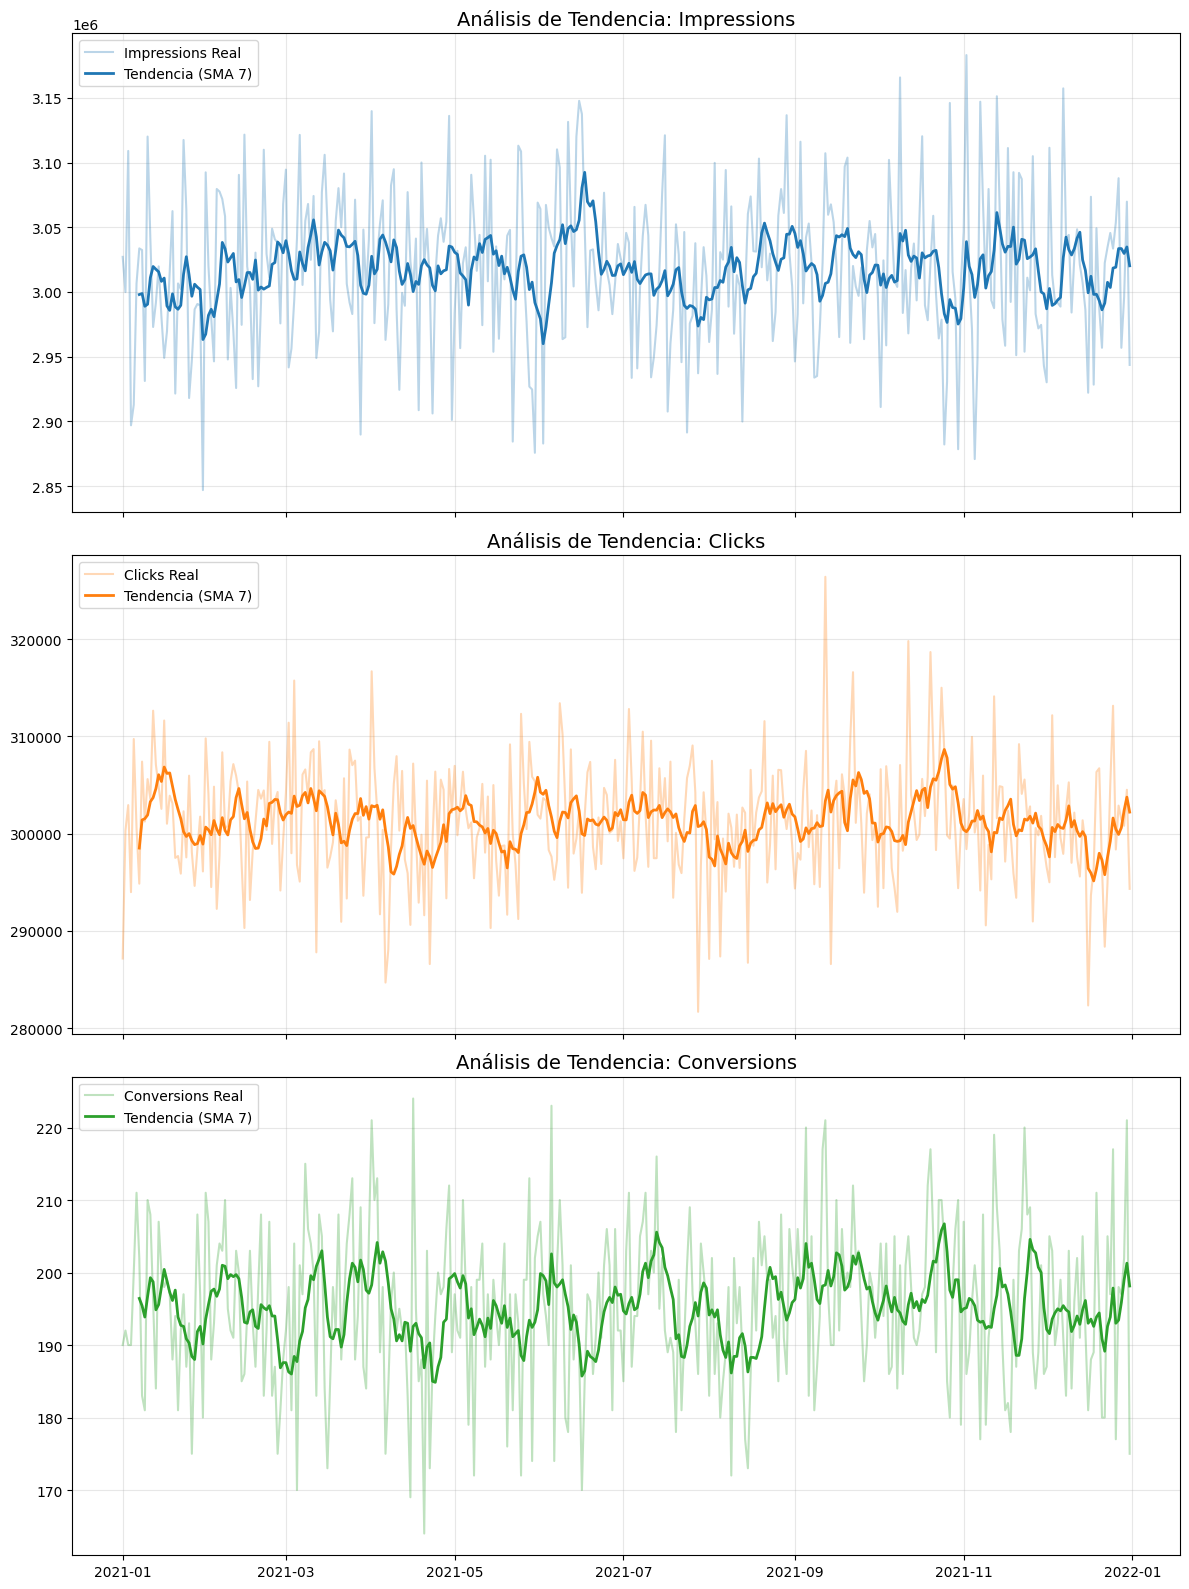

In [ ]:
df_var_obj.set_index("Date", inplace=True)

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(12, 16), sharex=True)

variables = ["Impressions","Clicks","Conversions"]
colors = ["#1f77b4","#ff7f0e","#2ca02c"]

for i, var in enumerate(variables):
    axs[i].plot(df_var_obj.index, df_var_obj[var], label=f"{var} Real", color=colors[i], alpha=0.3)

    trend = df_var_obj[var].rolling(window=7).mean()
    axs[i].plot(df_var_obj.index, trend, label="Tendencia (SMA 7)", color=colors[i], linewidth=2)

    axs[i].set_title(f"Análisis de Tendencia: {var}", fontsize=14)
    axs[i].legend(loc="upper left")
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Tendencia nula y estacionariedad evidente
No se observa una tendencia alcista o bajista a largo plazo (tendencia nula), lo que indica que el volumen de actividad se mantiene en un rango constante a lo largo del año

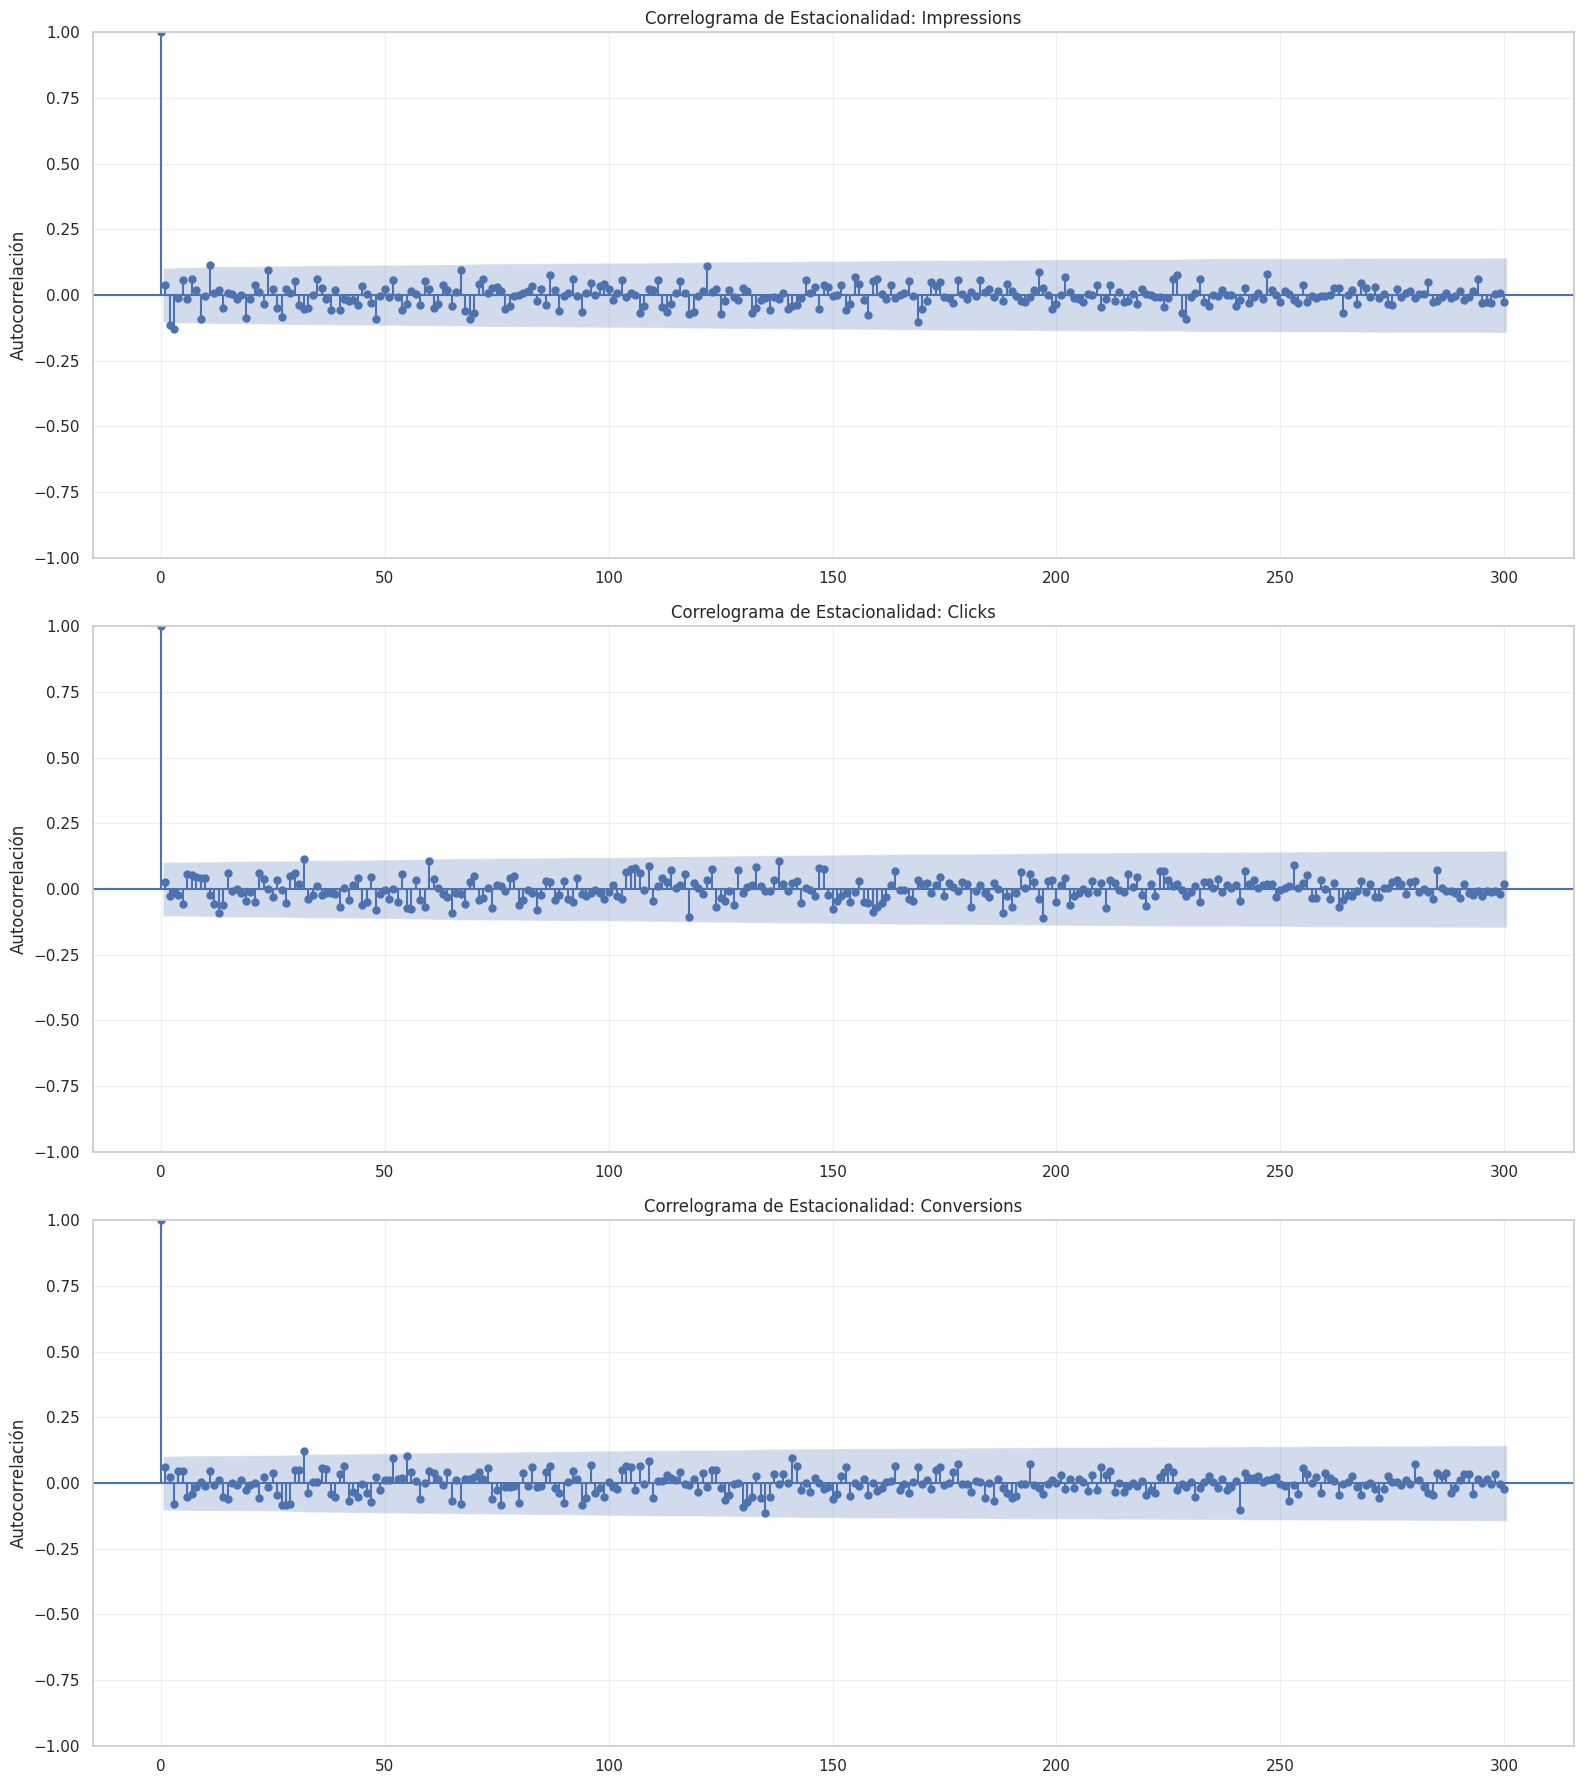

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(16, 18))
variables =  ["Impressions","Clicks","Conversions"]

for i, var in enumerate(variables):
    data_clean = df_var_obj[var].dropna()
    plot_acf(data_clean, ax=axs[i], lags=300, title=f"Correlograma de Estacionalidad: {var}")
    axs[i].set_ylabel("Autocorrelación")
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Adiós a la estacionalidad, hola al contexto de campaña
Los correlogramas muestran barras muy cortas que suben y bajan alrededor del cero sin un orden claro, lo que significa que se comporta como irregulares o eventos independientes. Sin una estacionalidad marcada, se confirma que los eventos de intercambio masivo son discontinuos y probablemente impulsados por la relevancia del mensaje y el contexto de la oferta, no por ciclos calendarios.

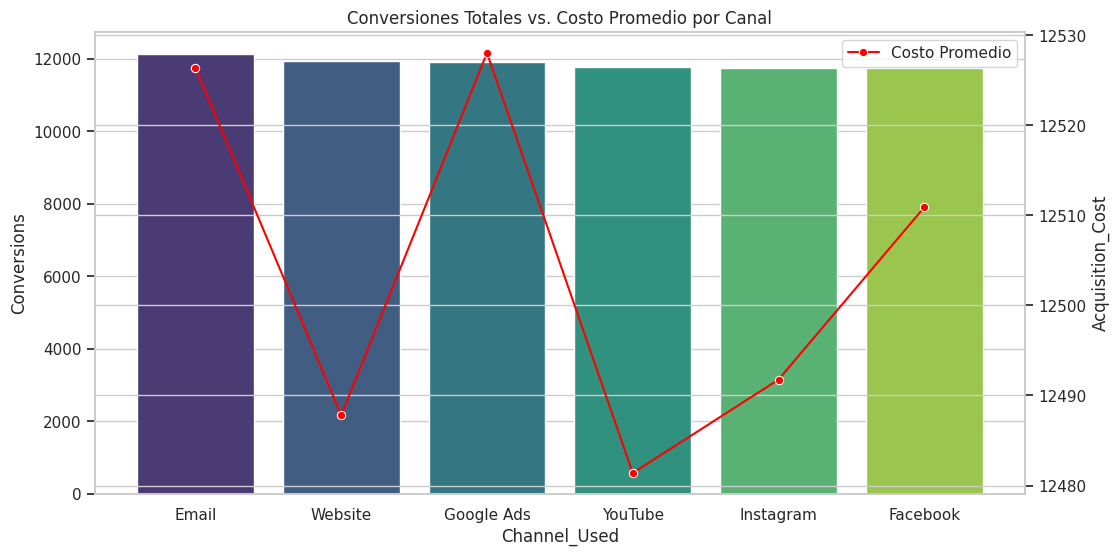

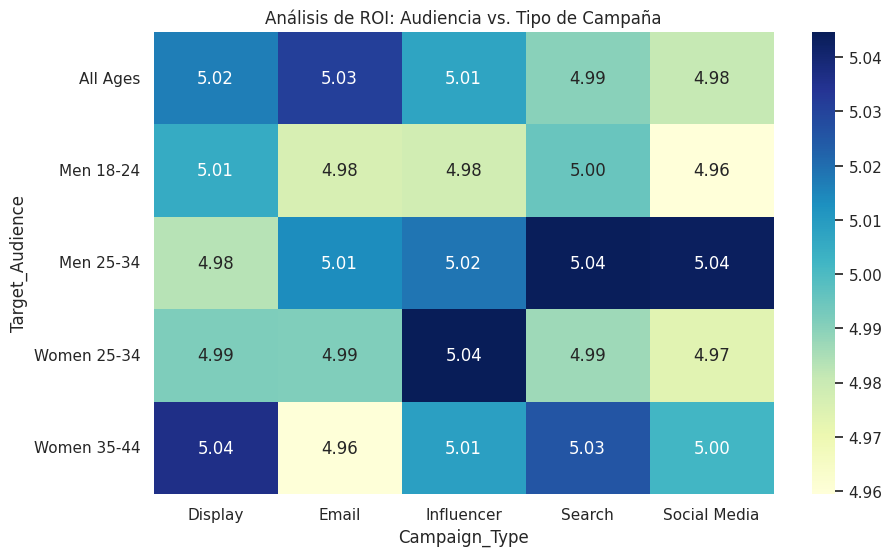

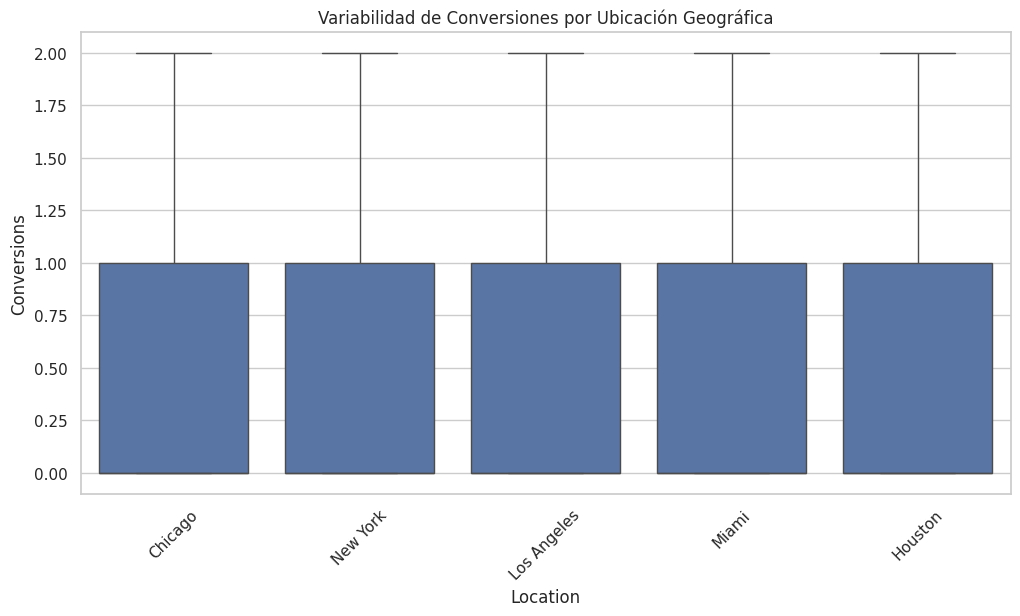

----------------------------------------------------------------------

### Resumen estratégico por tipo de campaña

,ROI,Conversion_Rate,Engagement_Score
Campaign_Type,,,
Influencer,5.011068,0.080315,5.483134
Search,5.008357,0.080021,5.487138
Display,5.006551,0.080089,5.505889
Email,4.994295,0.079788,5.499624
Social Media,4.991784,0.080135,5.497878


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df_channel = df.groupby("Channel_Used").agg({
    "Conversions": "sum",
    "Acquisition_Cost": "mean"
}).sort_values(by="Conversions", ascending=False).reset_index()

fig, ax1 = plt.subplots()

sns.barplot(data=df_channel, x="Channel_Used", y="Conversions", ax=ax1, palette="viridis", hue="Channel_Used", legend=False)
ax2 = ax1.twinx()
sns.lineplot(data=df_channel, x="Channel_Used", y="Acquisition_Cost", ax=ax2, color="red", marker="o", label="Costo Promedio")

ax1.set_title("Conversiones Totales vs. Costo Promedio por Canal")
plt.show()

pivot_roi = df.pivot_table(index="Target_Audience",
                           columns="Campaign_Type",
                           values="ROI",
                           aggfunc="mean")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_roi, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Análisis de ROI: Audiencia vs. Tipo de Campaña")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Location", y="Conversions")
plt.xticks(rotation=45)
plt.title("Variabilidad de Conversiones por Ubicación Geográfica")
plt.show()

insights = df.groupby("Campaign_Type").agg({
    "ROI": "mean",
    "Conversion_Rate": "mean",
    "Engagement_Score": "mean"
}).sort_values(by="ROI", ascending=False)

display(Markdown("-" * 70))
display(Markdown("### Resumen estratégico por tipo de campaña"))
display(insights)

#### Random Forest: rendimiento histórico y segmentación por dimensiones operativas
Al integrar métricas de eficiencia en costos y la sinergia de variables autorregresivas (lags) de rendimiento mediante una **arquitectura de regresión multi-salida (Multi-Output Regression)**, el modelo captura simultáneamente el contexto estratégico y la inercia operativa inmediata del negocio, este enfoque permite que las proyecciones de conversión dependan de manera directa de la configuración de la campaña y su tracción previa. Por último, para mitigar la convergencia asintótica lineal típica de los modelos iterativos y modelar la naturaleza estocástica del ecosistema digital, se acopló un **motor de simulación de Montecarlo** fundamentado en la distribución del residuo histórico.

In [ ]:
selcted_var = "Campaign_Type"
segment_category = "Email"

df_segmented = df[df[selcted_var] == segment_category].copy()

df_grouped = df_segmented.groupby("Date").agg({
    "Conversions": "sum",
    "Acquisition_Cost": "sum",
    "Clicks": "sum",
    "Impressions": "sum",
    "ROI": "mean",
    "Conversion_Rate": "mean"
}).reset_index().sort_values("Date")

df_grouped["CTR"] = (df_grouped["Clicks"] / df_grouped["Impressions"]).replace([np.inf, -np.inf], 0).fillna(0)
df_grouped["CPC"] = (df_grouped["Acquisition_Cost"] / df_grouped["Clicks"]).replace([np.inf, -np.inf], 0).fillna(0)
df_grouped["CPM"] = (df_grouped["Acquisition_Cost"] / df_grouped["Impressions"]) * 1000).replace([np.inf, -np.inf], 0).fillna(0)
df_grouped["Conversions_Lag1"] = df_grouped.groupby("Campaign_Type")["Conversions"].shift(1)
df_grouped["Clicks_Lag1"] = df_grouped.groupby("Campaign_Type")["Clicks"].shift(1)
df_grouped["ROI_Lag1"] = df_grouped["ROI"].shift(1)
df_grouped["day_of_week"] = df_grouped["Date"].dt.dayofweek

df_final = df_grouped.dropna()

split_idx = int(len(df_final) * 0.8)
df_train = df_final.iloc[:split_idx]
df_test = df_final.iloc[split_idx:]

X_train = df_train.drop(["Date", "Conversions"], axis=1)
X_test = df_test.drop(["Date", "Conversions"], axis=1)
y_train = df_train["Conversions"]
y_test = df_test["Conversions"]

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

model = RandomForestRegressor(n_estimators=100,
                              max_depth=6,
                              min_samples_leaf=5,
                              random_state=42)

model.fit(X_train, y_train)

preds = model.fit(X_train, y_train).predict(X_test)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

mean_test_conversions = y_test.mean()
cv_rmse = (rmse / mean_test_conversions) * 100

display(Markdown("#### --- RESULTADOS DE VALIDACIÓN DEL MODELO ---"))
print(f"Coeficiente de Determinación (R²): {round(r2, 4)}")
print(f"Error Cuadrático Medio Raíz Relativo (RMSE): {round(cv_rmse, 2)}")
print("-" * 70)
print(f"Interpretación: El modelo explica el {round(r2*100, 2)}% de la variación en ventas.")
if r2 > 0.75 and cv_rmse <= 10:
    print("Estado: MODELO VALIDADO PARA PRODUCCIÓN (EXCELENTE).")
elif r2 > 0.6 and cv_rmse <= 25:
    print("Estado: MODELO VALIDADO PARA PRODUCCIÓN (ACEPTABLE).")
else:
    print("Estado: REVISAR SEGMENTACIÓN - Precisión por debajo del umbral objetivo.")

#### --- RESULTADOS DE VALIDACIÓN DEL MODELO ---

Coeficiente de Determinación (R²): 0.6932
Error Cuadrático Medio Raíz Relativo (RMSE): 8.62
----------------------------------------------------------------------
Interpretación: El modelo explica el 69.32% de la variación en ventas.
Estado: MODELO VALIDADO PARA PRODUCCIÓN (EXCELENTE).


#### Herramienta interactiva que realiza proyecciones de conversiones basadas en las categorías de variables de contexto

In [ ]:
numerical_features = ["Conv_Lag1", "ROI_Lag1", "Clicks_Lag1", "day_of_week", "CTR", "CPC", "CPM"]
targets = ["Conversions", "ROI", "Conversion_Rate"]

random_forest_forecast = RandomForestRegressor(n_estimators=100,
                                               max_depth=6,
                                               random_state=42,
                                               n_jobs=1)

factor_top_b = html.B(children=[], id="factor")
value_top_b = html.B(children=[], id="value")

ROI = html.B(children=[], id="ROI")
CVR = html.B(children=[], id="CVR")
CPC = html.B(children=[], id="CPC")

vars = [
    {"label":"Tipo de campaña","value":"Campaign_Type"},
    {"label":"Compañía","value":"Company"},
    {"label":"Canal usado","value":"Channel_Used"},
    {"label":"Locación","value":"Location"}
]

app = dash.Dash(__name__)

app.layout =  html.Div(id="body", className="e6_body", children=[
    html.H1("Análisis por dimensiones personalizadas", id="H1", className="e6_title"),
    html.Div(id="dropdown_div_1", className="e6_dropdown_div_1", children=[
    dcc.Dropdown(id="dropdown_vars", className="e6_dropdown_1",
                options=vars,
                value="Campaign_Type",
                multi=False,
                clearable=False),
    ]),
    html.Div(id="graph_div_1", className="e6_graph_div_1", children=[
        html.Div(id="KPI_div_1", className="e6_KPI_div_1", children=[
            html.P(factor_top_b, className="e6_KPI_1", style={"margin-right":"20px"}),
            html.P(value_top_b, className="e6_KPI_1", style={"margin-left":"20px"})
        ]),
        dcc.Graph(id="conversions_analysis", figure={}, className="e6_graph_1")
    ]),
    html.H2("Proyección de conversiones (modelos promocionales)", id="H2", className="e6_title"),
    html.Div(id="forecast_div", className="e6_forecast_div", children=[
        html.Div(id="KPI_div_2", className="e6_KPI_div_2", children=[
            html.Div(className="e6_KPI_2", children=[html.P("ROI", className="e6_KPI_title"), html.P([ROI,"%"], className="e6_KPI_p")]),
            html.Div(className="e6_KPI_2", children=[html.P("CVR", className="e6_KPI_title"), html.P([CVR,"%"], className="e6_KPI_p")]),
            html.Div(className="e6_KPI_2", children=[html.P("CPC", className="e6_KPI_title"), html.P(["$",CPC], className="e6_KPI_p")])
        ]),
        html.Div(id="graph_div_2", className="e6_graph_div_2", children=[
        html.Div(id="dropdown_div_2", className="e6_dropdown_div_2", children=[
            dcc.Dropdown(id="dropdown_var1", className="e6_dropdown_2",
                        options=df["Campaign_Type"].unique(),
                        value=df["Campaign_Type"].unique()[0],
                        multi=False,
                        clearable=False),
            dcc.Dropdown(id="dropdown_var2", className="e6_dropdown_2",
                        options=df["Company"].unique(),
                        value=df["Company"].unique()[0],
                        multi=False,
                        clearable=False),
            dcc.Dropdown(id="dropdown_var3", className="e6_dropdown_2",
                        options=df["Channel_Used"].unique(),
                        value=df["Channel_Used"].unique()[0],
                        multi=False,
                        clearable=False),
            dcc.Dropdown(id="dropdown_var4", className="e6_dropdown_2",
                        options=df["Location"].unique(),
                        value=df["Location"].unique()[0],
                        multi=False,
                        clearable=False)
        ]),
        dcc.Graph(id="forecasting", figure={}, className="e6_graph_2")
        ])
    ])
])


@app.callback(
    [Output(component_id="factor",component_property="children"),
    Output(component_id="value",component_property="children"),
    Output(component_id="conversions_analysis",component_property="figure"),
    Output(component_id="dropdown_var1",component_property="style"),
    Output(component_id="dropdown_var2",component_property="style"),
    Output(component_id="dropdown_var3",component_property="style"),
    Output(component_id="dropdown_var4",component_property="style"),
    Output(component_id="forecasting",component_property="figure"),
    Output(component_id="ROI",component_property="children"),
    Output(component_id="CVR",component_property="children"),
    Output(component_id="CPC",component_property="children")],
    [Input(component_id="dropdown_vars",component_property="value"),
    Input(component_id="dropdown_var1",component_property="value"),
    Input(component_id="dropdown_var2",component_property="value"),
    Input(component_id="dropdown_var3",component_property="value"),
    Input(component_id="dropdown_var4",component_property="value")]
)

def update_forecast(slct_var, slct_campaign, slct_company, slct_channel, slct_location):

    campaign_style = {"position":"absolute","top":"0","left":"0", "zIndex": 1}
    company_style = {"position":"absolute","top":"0","left":"0", "zIndex": 1}
    channel_style = {"position":"absolute","top":"0","left":"0", "zIndex": 1}
    location_style = {"position":"absolute","top":"0","left":"0", "zIndex": 1}

    if slct_var == "Campaign_Type":
        campaign_style["zIndex"] = 5
        df_segment = df[df[slct_var] == slct_campaign].copy()
    elif slct_var == "Company":
        company_style["zIndex"] = 5
        df_segment = df[df[slct_var] == slct_company].copy()
    elif slct_var == "Channel_Used":
        channel_style["zIndex"] = 5
        df_segment = df[df[slct_var] == slct_channel].copy()
    else:
        location_style["zIndex"] = 5
        df_segment = df[df[slct_var] == slct_location].copy()

    if df_segment.empty or len(df_segment) < 3:
        return "Sin datos", "0%", go.Figure(), campaign_style, company_style, channel_style, location_style, go.Figure(), 0, 0, 0

    df_ts = df_segment.groupby("Date").agg({
        "Conversions": "sum",
        "Acquisition_Cost": "sum",
        "Clicks": "sum",
        "Impressions": "sum",
        "ROI": "mean",
        "Conversion_Rate": "mean"
    }).reset_index().sort_values("Date")

    df_ts["CTR"] = (df_ts["Clicks"] / df_ts["Impressions"]).replace([np.inf, -np.inf], 0).fillna(0)
    df_ts["CPC"] = (df_ts["Acquisition_Cost"] / df_ts["Clicks"]).replace([np.inf, -np.inf], 0).fillna(0)
    df_ts["CPM"] = ((df_ts["Acquisition_Cost"] / df_ts["Impressions"]) * 1000).replace([np.inf, -np.inf], 0).fillna(0)
    df_ts["Conv_Lag1"] = df_ts["Conversions"].shift(1)
    df_ts["ROI_Lag1"] = df_ts["ROI"].shift(1)
    df_ts["Clicks_Lag1"] = df_ts["Clicks"].shift(1)
    df_ts["day_of_week"] = df_ts["Date"].dt.dayofweek

    df_model = df_ts.dropna()

    X= df_model[numerical_features]
    y = df_model[targets]
    final_features = list(X.columns)

    random_forest_forecast.fit(X, y)
    importance = np.mean([est.feature_importances_ for est in random_forest_forecast.estimators_], axis=0)

    df_imp = pd.DataFrame({
        "factor": final_features,
        "importance": importance
    }).sort_values(by="importance", ascending=True)

    top_row = df_imp.iloc[-1]
    factor_top_text = f"Impulsor principal: {top_row["factor"]}"
    value_top_text = f"Influencia en el éxito: {round(top_row["importance"] * 100, 1)}%"

    slct_label = next((opt["label"] for opt in vars if opt["value"] == slct_var), "Variable")

    bar_chart = px.bar(
        df_imp.tail(3),
        x="importance",
        y="factor",
        orientation="h",
        title=f"Impacto de los Factores en el éxito por {slct_label}",
        color="importance",
        color_continuous_scale="Blues"
    )

    bar_chart.update_layout(
        height=350,
        autosize=False,
        showlegend=False,
        margin=dict(l=20, r=20, t=40, b=20),
        template="plotly_white"
    )

    future_dates = pd.date_range(df_model["Date"].max() + pd.Timedelta(days=1), periods=14)
    last_row = df_model.iloc[-1]
    mean_cost, mean_clicks = df_ts["Acquisition_Cost"].mean(), df_ts["Clicks"].mean()
    last_cpc = mean_cost / mean_clicks if mean_clicks > 0 else 0

    dates, conversions, ROIs, CVRs, CPCs = [last_row["Date"]], [last_row["Conversions"]], [last_row["ROI"]], [last_row["Conversion_Rate"]], [last_cpc]
    curr_conv, curr_roi, curr_clicks_lag, curr_ctr, curr_cpc, curr_cpm = last_row["Conversions"], last_row["ROI"], mean_clicks, last_row["CTR"], last_row["CPC"], last_row["CPM"]

    dummy_pred_row = X.iloc[[-1]].copy()

    y_pred_hist = random_forest_forecast.predict(X)[:, 0]
    residuals = df_model["Conversions"] - y_pred_hist
    std_residual = residuals.std()
    np.random.seed(42)

    for date in future_dates:
        dummy_pred_row["Conv_Lag1"] = curr_conv
        dummy_pred_row["ROI_Lag1"] = curr_roi
        dummy_pred_row["Clicks_Lag1"] = curr_clicks_lag
        dummy_pred_row["day_of_week"] = date.dayofweek
        dummy_pred_row["CTR"] = curr_ctr
        dummy_pred_row["CPC"] = curr_cpc
        dummy_pred_row["CPM"] = curr_cpm

        res = random_forest_forecast.predict(dummy_pred_row[final_features])
        cpc_pred = mean_cost / mean_clicks if mean_clicks > 0 else 0

        noise = np.random.normal(0, std_residual)

        dates.append(date)
        conversions.append(res[0][0] + noise)
        ROIs.append(res[0][1])
        CVRs.append(res[0][2])
        CPCs.append(cpc_pred)

        curr_conv, curr_roi = res[0], res[1]

    df_forecast = pd.DataFrame({
        "Date": dates,
        "Conversions": conversions,
        "ROI": ROIs,
        "CVR": CVRs,
        "CPC": CPCs
    })

    df_ts_recent = df_ts[df_ts["Date"] >= "2021-10-01"]

    forecasting = go.Figure()
    forecasting.add_trace(go.Scatter(x=df_ts_recent["Date"], y=df_ts_recent["Conversions"], mode="lines", fill="tozeroy", fillcolor="rgba(0, 0, 255, 0.15)", name="Conversiones Históricas"))
    forecasting.add_trace(go.Scatter(x=df_forecast["Date"], y=df_forecast["Conversions"], mode="lines+markers", fill="tozeroy", fillcolor="rgba(255, 165, 0, 0.15)", name="Pronóstico de 14 días"))
    forecasting.update_layout(template="plotly_white", margin=dict(l=20, r=20, t=40, b=20), xaxis_title="Fecha", yaxis_title="Conversiones")

    ROI_val = str(round(df_forecast["ROI"].mean(), 2))
    CVR_val = str(round(df_forecast["CVR"].mean(), 2))
    CPC_val = str(round(df_forecast["CPC"].mean(), 2))

    return factor_top_text, value_top_text, bar_chart, campaign_style, company_style, channel_style, location_style, forecasting, ROI_val, CVR_val, CPC_val


if __name__ == "__main__":
    app.run(debug=False)